# Задание 1
- Реализовать по формуле выше свёртку двух ступенчатых сигналов:

$$f(x) = \begin{cases}
  	1, если  0 < x < 1 \\\\
  	0, иначе
  \end{cases}$$


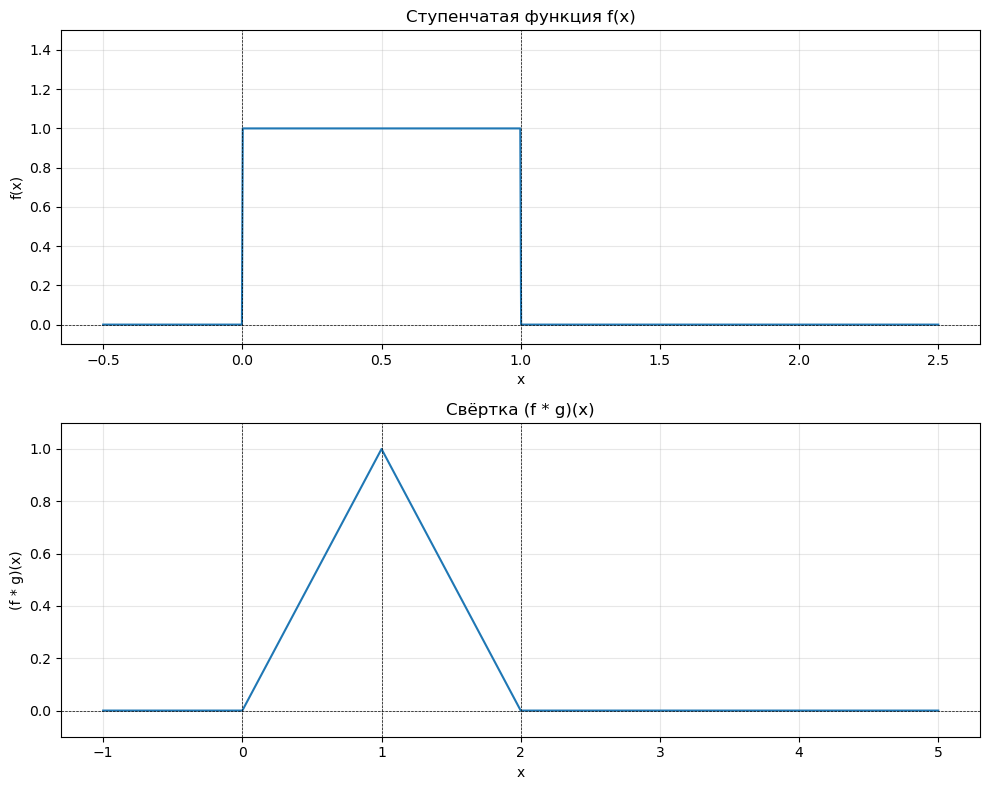

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def step_function(x):
    return np.where((x > 0) & (x < 1), 1.0, 0.0)

x = np.linspace(-0.5, 2.5, 1000)
dx = x[1] - x[0]

f = step_function(x)
g = step_function(x)

def convolution(f, g, dx):
    """
    Вычисляет свёртку двух дискретных сигналов
    (f * g)[n] = Σ f[m] * g[n-m] * dx
    """
    N = len(f)
    M = len(g)

    # Длина результата свёртки: N + M - 1
    conv_length = N + M - 1
    result = np.zeros(conv_length)
    
    for n in range(conv_length):
        for m in range(N):
            if 0 <= (n - m) < M:
                result[n] += f[m] * g[n - m] * dx
    
    return result

conv_result = convolution(f, g, dx)

x_conv = np.linspace(2*x[0], 2*x[-1], len(conv_result))

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(x, f)
axes[0].axhline(y=0, color='k', linewidth=0.5, linestyle='--')
axes[0].axvline(x=0, color='k', linewidth=0.5, linestyle='--')
axes[0].axvline(x=1, color='k', linewidth=0.5, linestyle='--')
axes[0].set_title('Ступенчатая функция f(x)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].set_ylim(-0.1, 1.5)
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_conv, conv_result)
axes[1].axhline(y=0, color='k', linewidth=0.5, linestyle='--')
axes[1].axvline(x=0, color='k', linewidth=0.5, linestyle='--')
axes[1].axvline(x=1, color='k', linewidth=0.5, linestyle='--')
axes[1].axvline(x=2, color='k', linewidth=0.5, linestyle='--')
axes[1].set_title('Свёртка (f * g)(x)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('(f * g)(x)')
axes[1].set_ylim(-0.1, 1.1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()


- То же самое, но с использованием готовых библиотек.

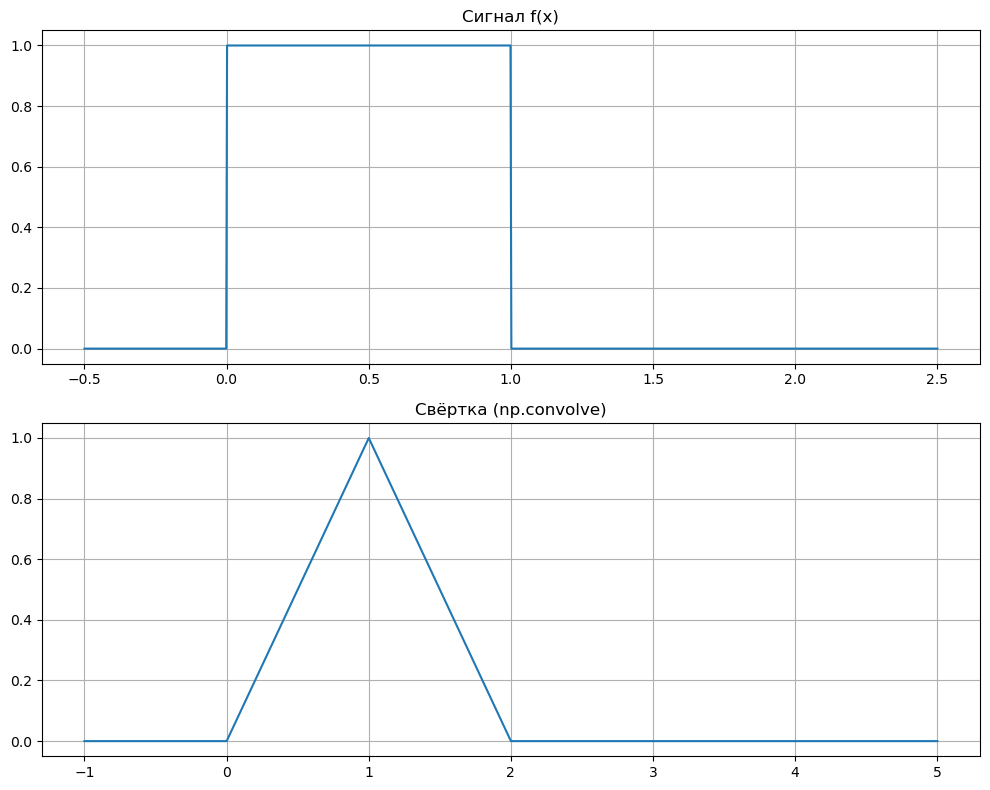

In [11]:
convolution_result = np.convolve(f, g, mode='full')

x_conv = np.linspace(2*x[0], 2*x[-1], len(convolution_result))

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(x, f)
axes[0].set_title('Сигнал f(x)')
axes[0].grid(True)

axes[1].plot(x_conv, convolution_result * dx)
axes[1].set_title('Свёртка (np.convolve)')
axes[1].grid(True)

plt.tight_layout()